In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


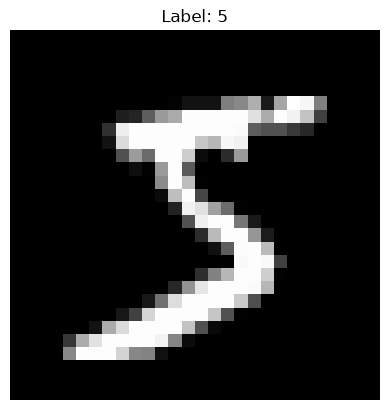

In [4]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

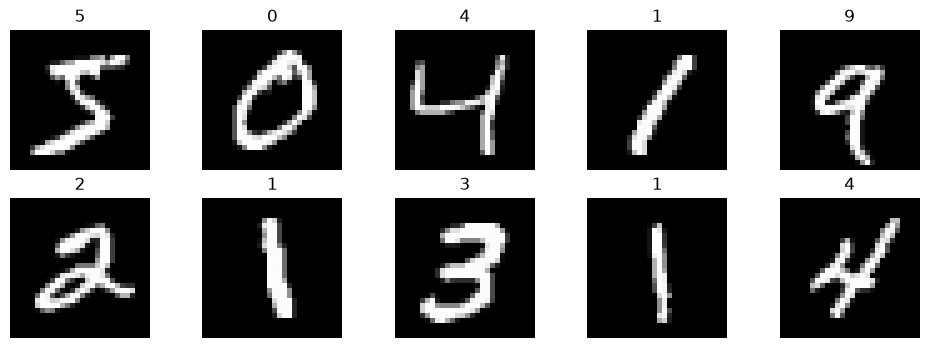

In [5]:
plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

c:\Users\ADMIN\OneDrive\Desktop\AI PROJECTS\Handwritten_Digit_Recognizer\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9194 - loss: 0.2718 - val_accuracy: 0.9451 - val_loss: 0.1847
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9658 - loss: 0.1139 - val_accuracy: 0.9699 - val_loss: 0.1012
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9752 - loss: 0.0789 - val_accuracy: 0.9695 - val_loss: 0.1006
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9817 - loss: 0.0578 - val_accuracy: 0.9682 - val_loss: 0.1022
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9858 - loss: 0.0451 - val_accuracy: 0.9737 - val_loss: 0.0893


In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9737 - loss: 0.0840
Test Accuracy: 0.9736999869346619


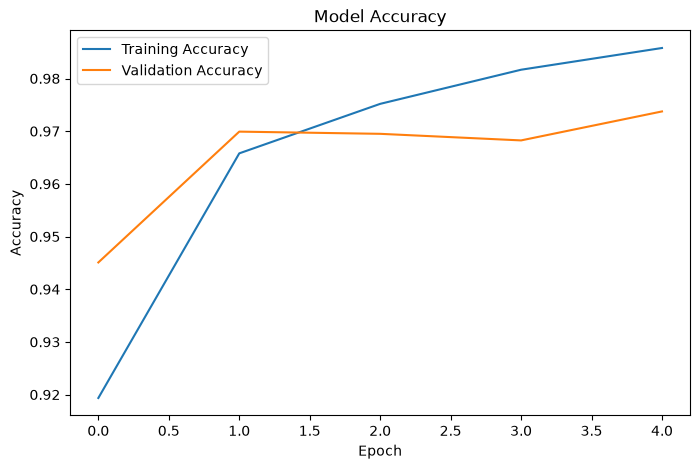

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.show()

In [13]:
model.save("digit_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
Predicted Digit: 7
Actual Digit: 7


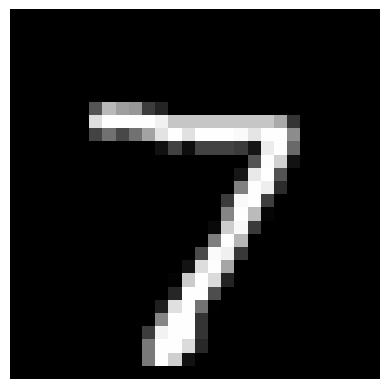

In [14]:
prediction = model.predict(X_test[:1])

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[0])

plt.imshow(X_test[0], cmap="gray")
plt.axis("off")
plt.show()

In [15]:
import cv2
from predict import predict_digit

image = cv2.imread("test_images/sample.png")

digit, confidence = predict_digit(image)

print("Predicted Digit:", digit)
print("Confidence:", confidence)

error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [16]:
import os

print(os.getcwd())
print(os.path.exists("test_images/sample.png"))

c:\Users\ADMIN\OneDrive\Desktop\AI PROJECTS\Handwritten_Digit_Recognizer
False


Predicted: 6
Actual: 6


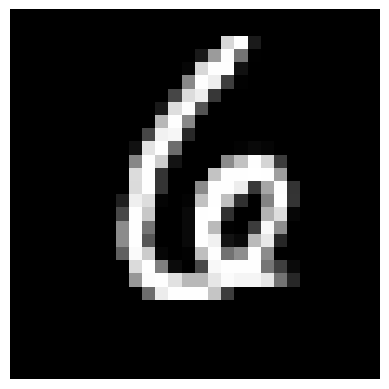

In [17]:
import matplotlib.pyplot as plt
import numpy as np

index = 123

prediction = model.predict(X_test[index:index+1], verbose=0)

print("Predicted:", np.argmax(prediction))
print("Actual:", y_test[index])

plt.imshow(X_test[index], cmap="gray")
plt.axis("off")
plt.show()